### Load company stock close price data

In [4]:
import yfinance as yf
import pandas as pd

# Long history tickers (10+ years)
tickers_ev = ["TSLA", "NIO", "BYDDF", "TM"]

# Download 'Close' prices for all tickers at once
data = yf.download(tickers_ev, start="2010-01-01")['Close']

# Reset index to get 'date' as a column
data = data.reset_index()

# Rename columns for consistency
data.columns = ['date'] + [f"{ticker}_close" for ticker in data.columns[1:]]

# Preview the merged DataFrame
data.head()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  4 of 4 completed


,date,BYDDF_close,NIO_close,TM_close,TSLA_close
0,2010-01-04,8.851574,NaN,58.215019,NaN
1,2010-01-05,8.802938,NaN,57.318668,NaN
2,2010-01-06,8.588945,NaN,58.050800,NaN
3,2010-01-07,8.355497,NaN,57.332352,NaN
4,2010-01-08,8.345769,NaN,58.680313,NaN


In [2]:
from alpha_vantage.timeseries import TimeSeries
import pandas as pd
import time

# Initialize API
api_key = "MZQGQ97JUS2KGPJ5"
ts = TimeSeries(key=api_key, output_format="pandas")

# Long history tickers (10+ years)
tickers_ev  = ["TSLA","NIO","BYDDF","TM"]

# Initialize merged DataFrame
long_term_stock_df = None

# Loop with rate limit protection
for i, ticker in enumerate(tickers_ev):
    data, _ = ts.get_daily(symbol=ticker, outputsize='full')
    data.index = pd.to_datetime(data.index)
    data = data.sort_index()
    data.columns = [f"{ticker}_{col}" for col in data.columns]
    data['date'] = data.index
    data = data.reset_index(drop=True)
    
    if long_term_stock_df is None:
        long_term_stock_df = data
    else:
        long_term_stock_df = pd.merge(long_term_stock_df, data, on='date', how='outer')

    time.sleep(15)  # Respect Alpha Vantage rate limit

ValueError: We have detected your API key as MZQGQ97JUS2KGPJ5 and our standard API rate limit is 25 requests per day. Please subscribe to any of the premium plans at https://www.alphavantage.co/premium/ to instantly remove all daily rate limits.

In [17]:
import pandas as pd
# long_term_stock_df = pd.read_csv("ev_stocks_merged_on_date.csv")
# short_term_stock_df = pd.read_csv("shortterm_ev_stocks_ts.csv")
long_term_stock_df = long_term_stock_df.sort_values(by="date")
# short_term_stock_df = short_term_stock_df.sort_values(by="date")
#long_term_stock_df = long_term_stock_df.dropna().set_index('date')
# short_term_stock_df = short_term_stock_df.dropna().set_index('date')
nio = long_term_stock_df[['BYDDF_4. close', 'date']].dropna().head()
nio

,BYDDF_4. close,date
0,6.40,2007-08-21
1,6.40,2007-08-22
2,6.85,2007-08-23
3,6.85,2007-08-24
4,6.85,2007-08-27


Load ETF Commodity Data

In [5]:
metal_etfs = pd.read_csv('data/AlphaVantage Metal ETFS/metal_etfs.csv')
JJN_cols = [col for col in metal_etfs.columns if 'JJN' in col.upper()]
JJC_cols = [col for col in metal_etfs.columns if 'JJC' in col.upper()]
metal_etfs = metal_etfs.rename(columns={'Unnamed: 0': 'date'}).drop(columns=JJN_cols + JJC_cols)
metal_etfs = metal_etfs.dropna().set_index('date')
metal_etfs.head()

,LIT_open,LIT_high,LIT_low,LIT_close,LIT_volume,COPX_open,COPX_high,COPX_low,COPX_close,COPX_volume,DBB_open,DBB_high,DBB_low,DBB_close,DBB_volume,PICK_open,PICK_high,PICK_low,PICK_close,PICK_volume
date,,,,,,,,,,,,,,,,,,,,
2012-02-02,17.00,17.140,16.987,17.1000,14800.0,15.36,15.6000,15.36,15.46,57800.0,20.91,21.000,20.6175,20.72,97500.0,25.75,25.9600,25.750,25.9600,400.0
2012-02-03,17.44,17.450,17.100,17.4300,35800.0,15.68,15.8200,15.62,15.78,68100.0,21.05,21.280,21.0100,21.25,143900.0,26.16,26.2700,26.129,26.2500,4000.0
2012-02-06,17.21,17.329,17.150,17.2500,19400.0,15.57,15.6600,15.47,15.59,67500.0,21.07,21.140,20.9700,21.01,160700.0,26.16,26.1900,26.160,26.1780,2800.0
2012-02-07,17.30,17.370,17.250,17.2699,13800.0,15.41,15.4676,15.22,15.28,48100.0,20.89,21.104,20.7904,21.00,204000.0,28.00,28.0000,26.120,26.1200,600.0
2012-02-08,17.42,17.440,17.220,17.4000,39600.0,15.46,15.5560,15.27,15.30,88600.0,21.29,21.394,21.1000,21.14,97800.0,26.12,26.3915,26.120,26.3915,400.0


In [6]:
import numpy as np
import pandas as pd

# Filter out any zero or negative values BEFORE log return calculation
long_term_stock_df = long_term_stock_df.replace(0, np.nan)
long_term_stock_df[long_term_stock_df < 0] = np.nan

metal_etfs = metal_etfs.replace(0, np.nan)
metal_etfs[metal_etfs < 0] = np.nan

## EDA

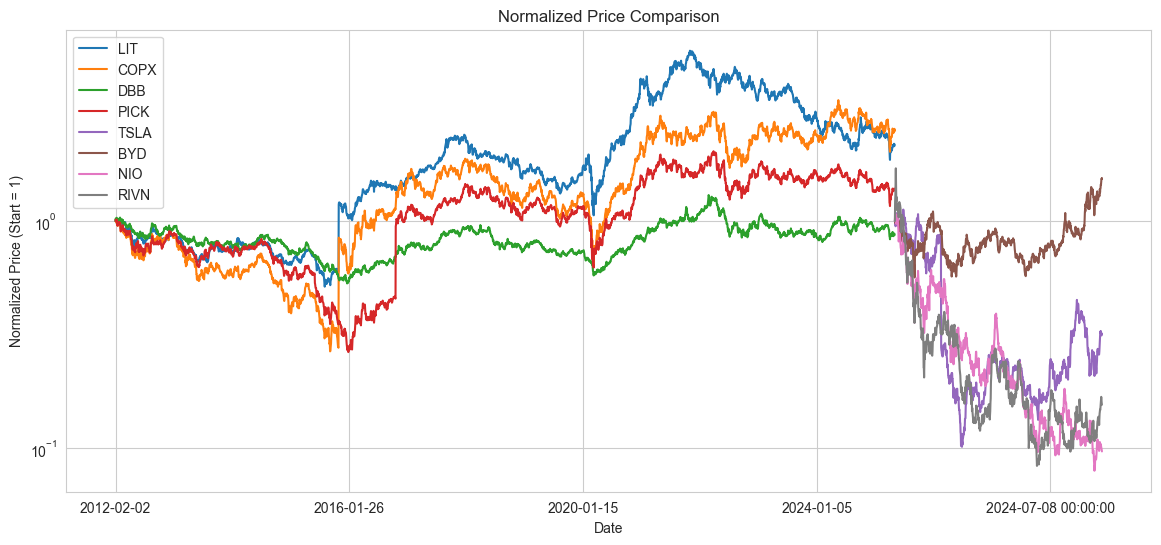

In [8]:
import matplotlib.pyplot as plt

normalized_df = pd.DataFrame({
    'LIT': metal_etfs['LIT_close'] / metal_etfs['LIT_close'].iloc[0],
    'COPX': metal_etfs['COPX_close'] / metal_etfs['COPX_close'].iloc[0],
    'DBB': metal_etfs['DBB_close'] / metal_etfs['DBB_close'].iloc[0],
    'PICK': metal_etfs['PICK_close'] / metal_etfs['PICK_close'].iloc[0],
    'TSLA': long_term_stock_df['TSLA_4. close'] / long_term_stock_df['TSLA_4. close'].iloc[0],
    'BYD': long_term_stock_df['BYDDF_4. close'] / long_term_stock_df['BYDDF_4. close'].iloc[0],
    'NIO': long_term_stock_df['NIO_4. close'] / long_term_stock_df['NIO_4. close'].iloc[0],
    'RIVN': long_term_stock_df['RIVN_4. close'] / long_term_stock_df['RIVN_4. close'].iloc[0]
    #'TM': long_term_stock_df['TM_4. close'] / long_term_stock_df['TM_4. close'].iloc[0],
    #'F': long_term_stock_df['F_4. close'] / long_term_stock_df['F_4. close'].iloc[0],
    #'GM': long_term_stock_df['GM_4. close'] / long_term_stock_df['GM_4. close'].iloc[0]
})

normalized_df.plot(figsize=(14,6), title='Normalized Price Comparison')
plt.xlabel('Date')
plt.ylabel('Normalized Price (Start = 1)')
plt.yscale('log')
plt.grid(True)
plt.show()

### Feature Engineering

,TSLA_high_low_spread,NIO_high_low_spread,BYDDF_high_low_spread,RIVN_high_low_spread,LIT_high_low_spread,COPX_high_low_spread,DBB_high_low_spread,PICK_high_low_spread,TSLA_close_open_diff,NIO_close_open_diff,...,DBB_volume_pct_change,PICK_volume_pct_change,TSLA_log_ret,NIO_log_ret,BYDDF_log_ret,RIVN_log_ret,LIT_log_ret,COPX_log_ret,DBB_log_ret,PICK_log_ret
date,,,,,,,,,,,,,,,,,,,,,


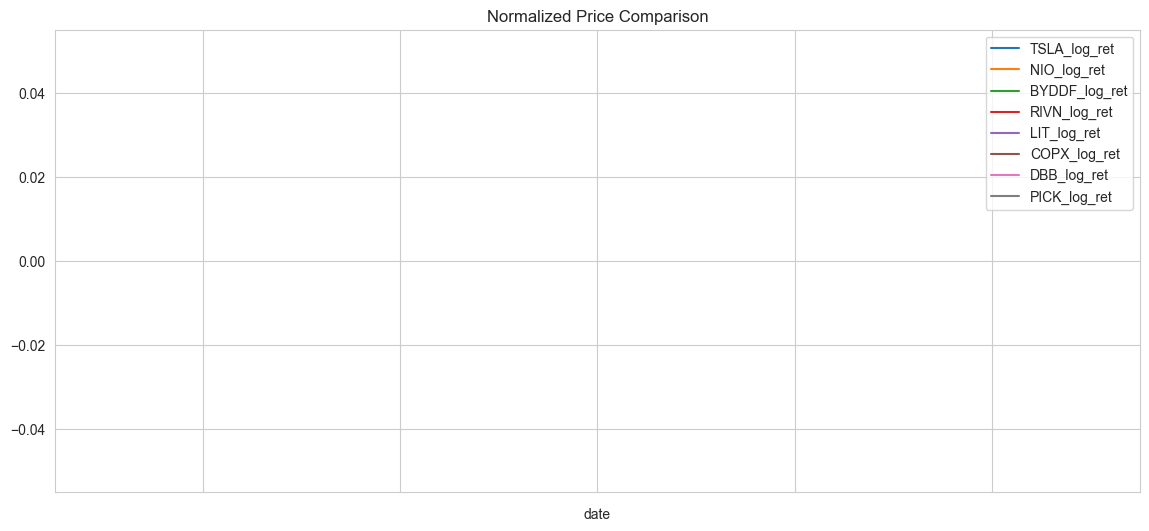

In [9]:
full_df = long_term_stock_df.join(metal_etfs, how='inner').sort_index()
close_cols = [col for col in full_df.columns if "close" in col.lower()]

# high - Low
high_cols = [col for col in full_df.columns if "high" in col.lower()]
low_cols = [col for col in full_df.columns if "low" in col.lower()]

for high, low in zip(high_cols, low_cols):
    name = high.split("_")[0] 
    full_df[f"{name}_high_low_spread"] = full_df[high] - full_df[low]

# close - open
close_cols = [col for col in full_df.columns if "close" in col.lower()]
open_cols = [col for col in full_df.columns if "open" in col.lower()]

for close, open_ in zip(close_cols, open_cols):
    name = close.split("_")[0]
    full_df[f"{name}_close_open_diff"] = full_df[close] - full_df[open_]

# change in Volume
volume_cols = [col for col in full_df.columns if "volume" in col.lower()]

for vol in volume_cols:
    name = vol.split("_")[0]
    full_df[f"{name}_volume_pct_change"] = full_df[vol].pct_change(fill_method=None)

# log returns
for close in close_cols:
    name = close.split("_")[0]
    log_ret_col = f"{name}_log_ret"
    full_df[log_ret_col] = np.log(full_df[close] / full_df[close].shift(1))
    
raw_patterns = ('close', 'open', 'high', 'low', 'volume')
raw_cols = [c for c in full_df.columns if c.endswith(raw_patterns)]
full_df = full_df.drop(columns=raw_cols)

# Subset log returns for plotting
log_ret_cols = [col for col in full_df.columns if col.endswith("_log_ret")]
full_df[log_ret_cols].plot(figsize=(14, 6), title='Normalized Price Comparison')
full_df.dropna().head()

### Granger Causality

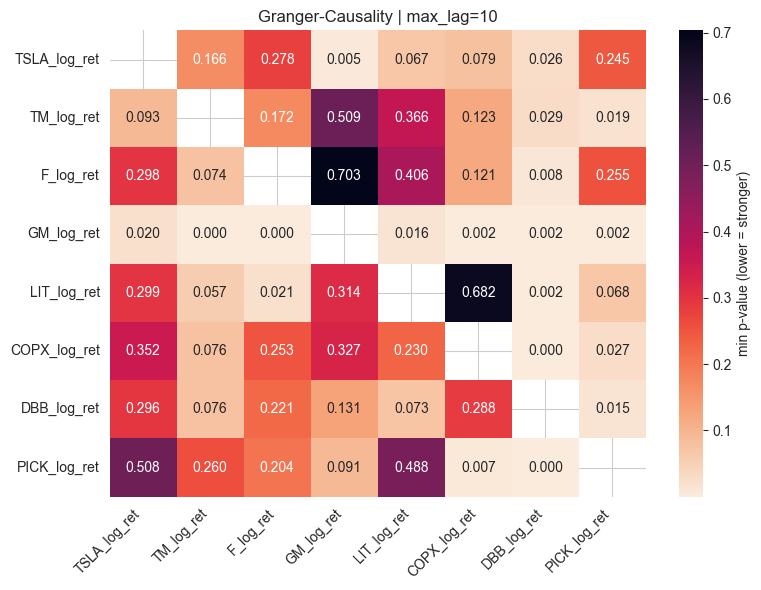

,TSLA_log_ret,TM_log_ret,F_log_ret,GM_log_ret,LIT_log_ret,COPX_log_ret,DBB_log_ret,PICK_log_ret
TSLA_log_ret,False,False,False,True,False,False,True,False
TM_log_ret,False,False,False,False,False,False,True,True
F_log_ret,False,False,False,False,False,False,True,False
GM_log_ret,True,True,True,False,True,True,True,True
LIT_log_ret,False,False,True,False,False,False,True,False
COPX_log_ret,False,False,False,False,False,False,True,True
DBB_log_ret,False,False,False,False,False,False,False,True
PICK_log_ret,False,False,False,False,False,True,True,False


p_value
PICK_log_ret DBB_log_ret   0.000003
GM_log_ret   F_log_ret     0.000256
             TM_log_ret    0.000349
COPX_log_ret DBB_log_ret   0.000455
GM_log_ret   COPX_log_ret  0.001605
             PICK_log_ret  0.001623
             DBB_log_ret   0.001735
LIT_log_ret  DBB_log_ret   0.001751
TSLA_log_ret GM_log_ret    0.004635
PICK_log_ret COPX_log_ret  0.007099

In [92]:
import pandas as pd
import numpy as np
import itertools
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="statsmodels")

max_lag   = 10
alpha     = 0.05 # significance threshold
plot_heat = True

log_returns = full_df[log_ret_cols].dropna()

min_rows_needed = (max_lag + 2) * 2 # rule-of-thumb
if len(log_returns) < min_rows_needed:
    raise ValueError(
        f"Only {len(log_returns)} rows—reduce max_lag below "
        f"{(len(log_returns)//2)-2} or fetch more history."
    )

# pairwise Granger
pv_matrix = pd.DataFrame(
    np.nan, index=log_ret_cols, columns=log_ret_cols, dtype=float
)
best_lags = {}

for x, y in itertools.permutations(log_ret_cols, 2):
    pvals = []
    for lag in range(1, max_lag + 1):
        try:
            test = sm.tsa.stattools.grangercausalitytests(
                log_returns[[x, y]], maxlag=lag, verbose=False
            )
            # F-test p-value for this lag
            p = test[lag][0]["ssr_ftest"][1]
            pvals.append((lag, p))
        except Exception:
            # happens if lag > samples/2 or series is collinear
            continue
    if pvals:
        # pick the lag with the *lowest* p-value
        best_lag, best_p = min(pvals, key=lambda tup: tup[1])
        pv_matrix.loc[y, x] = best_p      # y → x
        best_lags[(y, x)] = best_lag

# causal flags + viz
causal_flags = pv_matrix < alpha

if plot_heat:
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        pv_matrix, annot=True, cmap="rocket_r", fmt=".3f",
        cbar_kws={'label': 'min p-value (lower = stronger)'}
    )
    plt.title(f"Granger-Causality | max_lag={max_lag}")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

display(causal_flags)   # Boolean matrix: True = “Y Granger-causes X”

# optional: inspect strongest links
(
    pv_matrix.stack()
    .sort_values()
    .to_frame("p_value")
    .loc[lambda df: df["p_value"] < alpha]
    .head(10)
)

## Ridge Regression with LagMaker and PurgedKFold

In [93]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

# Purged K-Fold helper
from datetime import timedelta

class LagMaker(BaseEstimator, TransformerMixin):
    def __init__(self, max_lag=15):
        self.max_lag = max_lag

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # make sure we’re working with a DataFrame
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X)

        Xlag = X.copy()
        for lag in range(1, self.max_lag + 1):
            Xlag = Xlag.join(X.shift(lag).add_suffix(f"_lag{lag}"))

        # stringify everything so sklearn can chill
        Xlag.columns = Xlag.columns.astype(str)

        return Xlag.fillna(0)

from sklearn.model_selection import BaseCrossValidator
import numpy as np

class PurgedKFold(BaseCrossValidator):
    def __init__(self, n_splits=5, purge_days=0, dates=None):
        self.n_splits   = n_splits
        self.purge_days = purge_days
        self.dates      = pd.to_datetime(dates)

    def split(self, X, y=None, groups=None):
        n   = len(X)
        idx = np.arange(n)
        fold_sizes      = np.full(self.n_splits, n // self.n_splits, dtype=int)
        fold_sizes[: n % self.n_splits] += 1

        cur = 0
        for size in fold_sizes:
            start, stop   = cur, cur + size
            test_indices  = idx[start:stop]

            # purge window
            t0 = self.dates[test_indices[0]]
            t1 = self.dates[test_indices[-1]]

            purge_mask = (
                (self.dates < t0 - pd.Timedelta(days=self.purge_days)) |
                (self.dates > t1 + pd.Timedelta(days=self.purge_days))
            )

            train_indices = idx[purge_mask]      # <-  no “.values”
            yield train_indices, test_indices
            cur = stop

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits



X = full_df.drop(columns=['TSLA_log_ret'])
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.dropna(inplace=True)
y = full_df.loc[X.index, 'TSLA_log_ret'].shift(-1)
y.dropna(inplace=True)
X = X.loc[y.index]
X.head()

,TSLA_high_low_spread,TM_high_low_spread,F_high_low_spread,GM_high_low_spread,LIT_high_low_spread,COPX_high_low_spread,DBB_high_low_spread,PICK_high_low_spread,TSLA_close_open_diff,TM_close_open_diff,...,COPX_volume_pct_change,DBB_volume_pct_change,PICK_volume_pct_change,TM_log_ret,F_log_ret,GM_log_ret,LIT_log_ret,COPX_log_ret,DBB_log_ret,PICK_log_ret
date,,,,,,,,,,,,,,,,,,,,,
2012-02-03,1.08,0.50,0.45,1.65,0.350,0.2000,0.2700,0.1410,0.74,0.01,...,0.178201,0.475897,9.000000,0.003143,0.042322,0.074108,0.019114,0.020487,0.025257,0.011109
2012-02-06,0.85,0.68,0.29,0.88,0.179,0.1900,0.1700,0.0300,0.70,0.13,...,-0.008811,0.116748,-0.300000,0.016085,0.013204,0.019668,-0.010381,-0.012114,-0.011358,-0.002747
2012-02-07,0.98,1.00,0.14,0.47,0.120,0.2476,0.3136,1.8800,-0.20,0.13,...,-0.287407,0.269446,-0.785714,0.024156,-0.006192,-0.018141,0.001153,-0.020085,-0.000476,-0.002218
2012-02-08,0.72,0.51,0.16,0.84,0.220,0.2860,0.2940,0.2715,0.33,-0.01,...,0.841996,-0.520588,-0.333333,0.017927,-0.003110,-0.018088,0.007505,0.001308,0.006645,0.010341
2012-02-09,1.47,0.89,0.23,0.72,0.240,0.1585,0.1501,0.1700,0.58,-0.46,...,-0.348758,0.536810,1.750000,-0.002100,-0.011751,-0.000388,-0.016807,0.011050,0.013625,-0.009575


## XGBoost With Granger Feature Selection

TSLA_log_ret test MSE: 0.00205


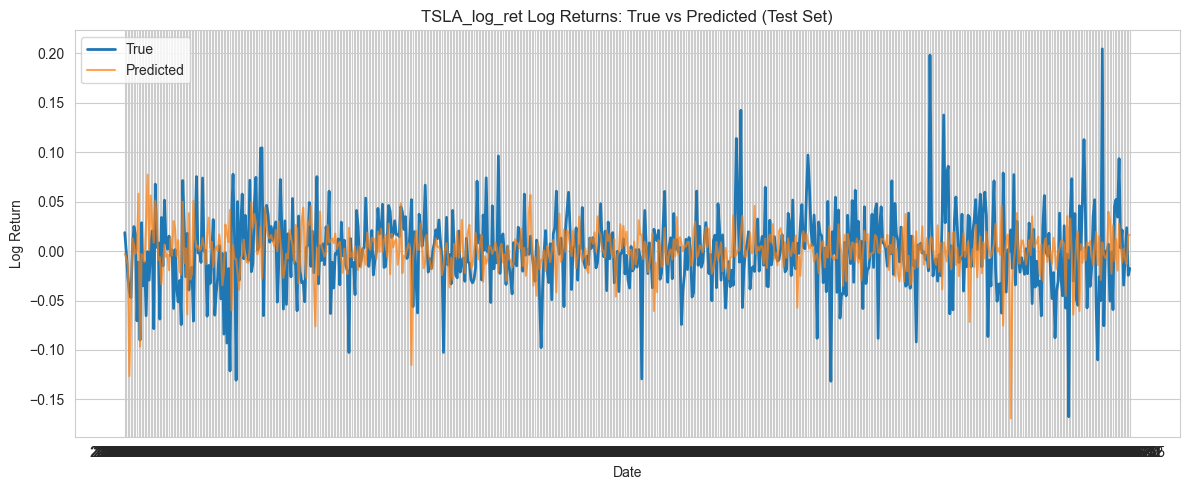

TM_log_ret test MSE: 0.00032


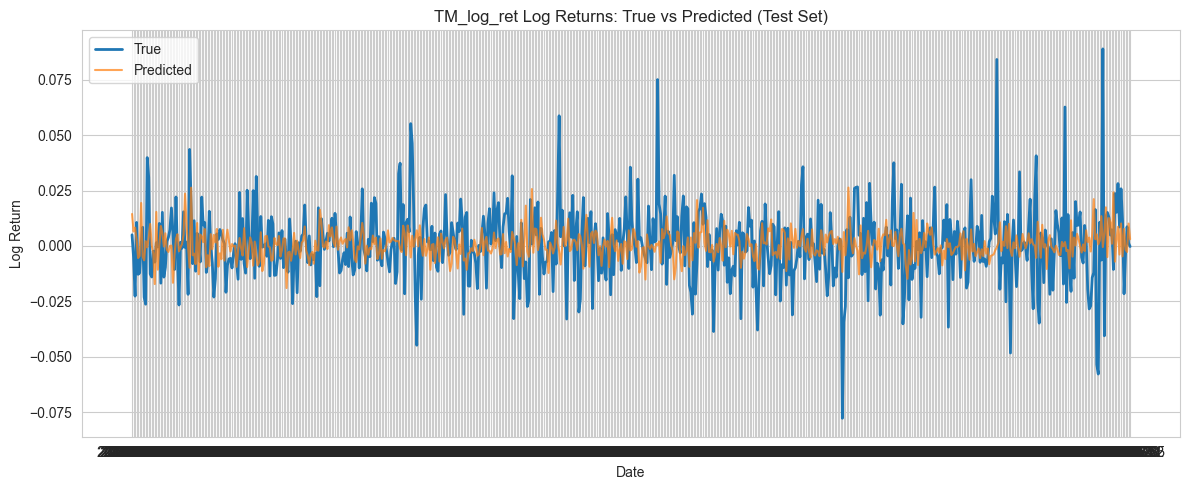

F_log_ret test MSE: 0.00071


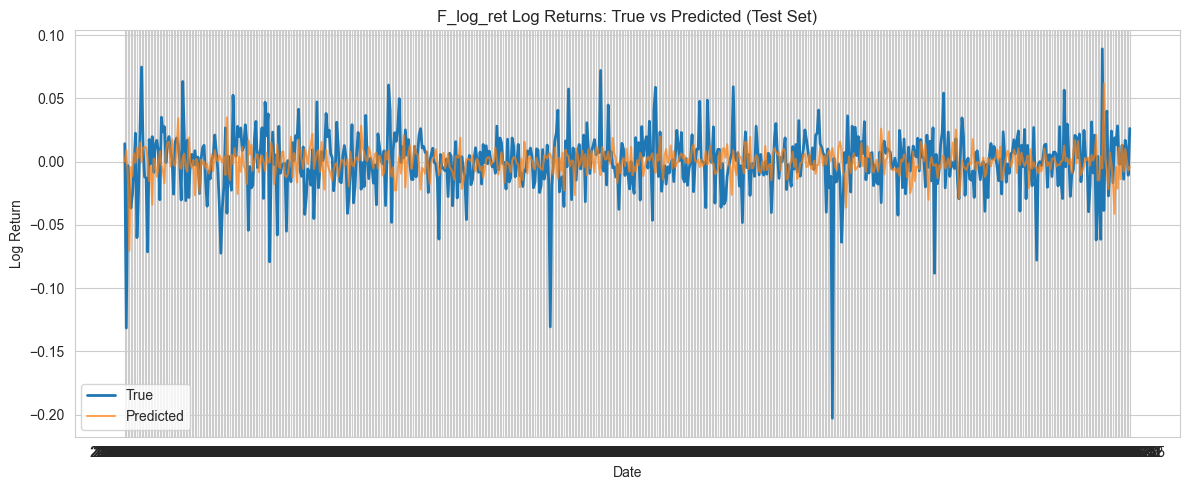

GM_log_ret test MSE: 0.00060


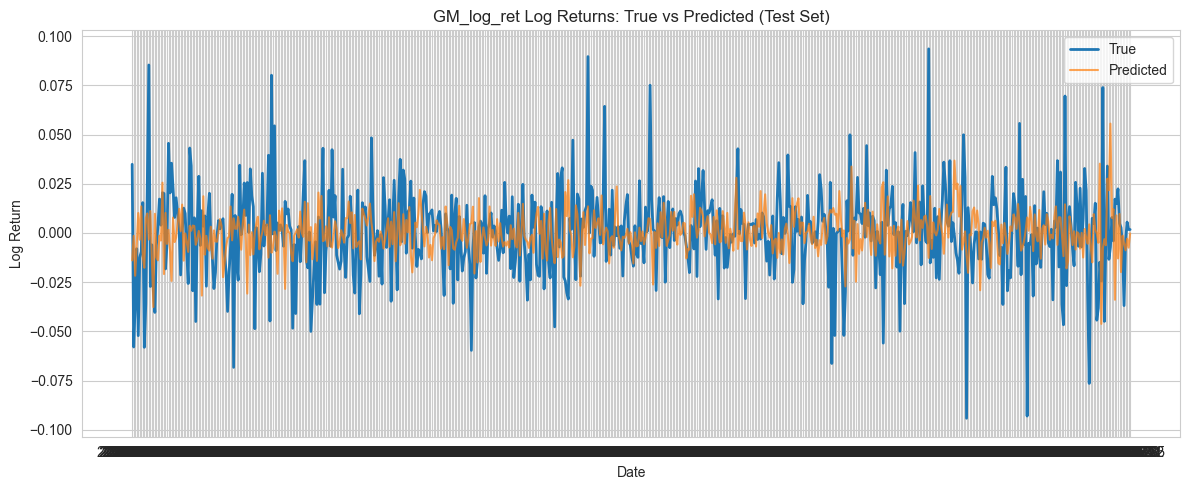

LIT_log_ret test MSE: 0.00053


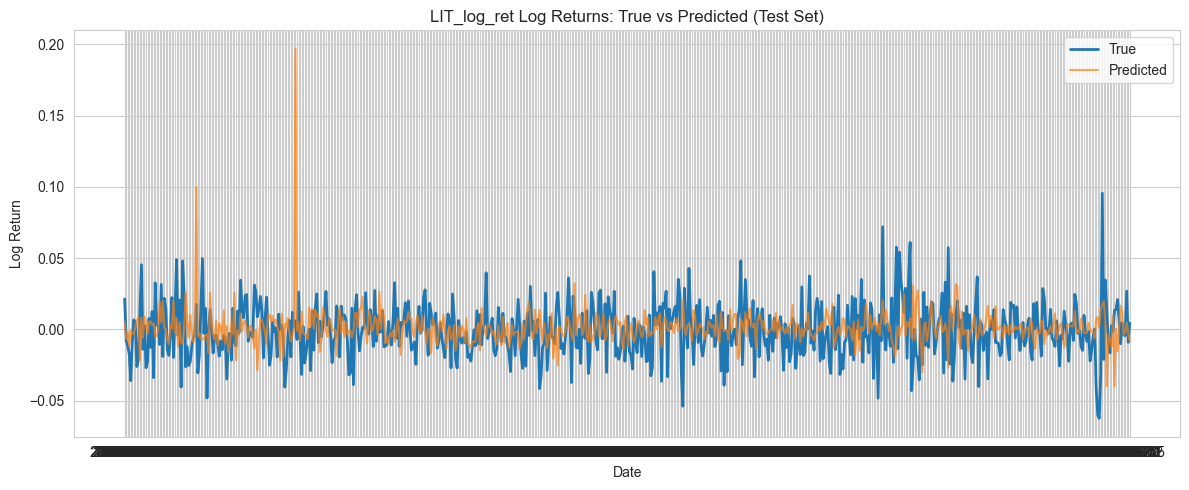

COPX_log_ret test MSE: 0.00061


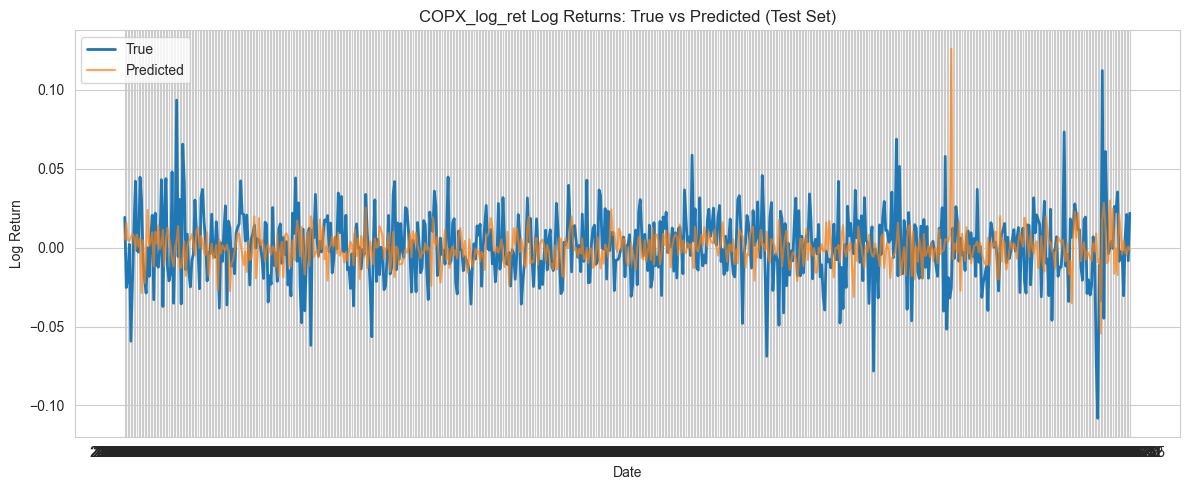

DBB_log_ret test MSE: 0.00018


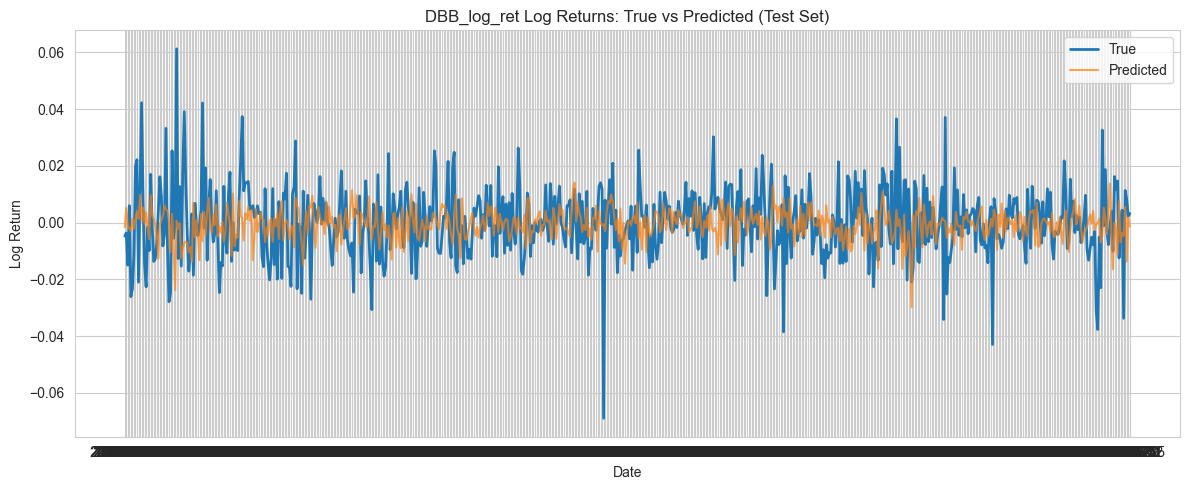

PICK_log_ret test MSE: 0.00052


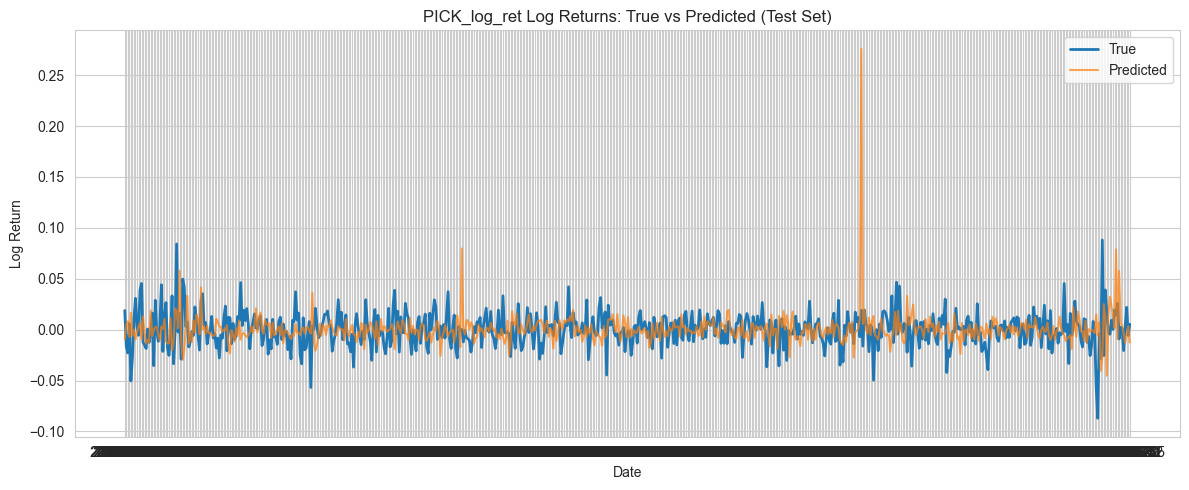

In [94]:
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

class GrangerFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, target_var, causal_flags, max_lag=10):
        self.target_var = target_var
        self.causal_flags = causal_flags
        self.max_lag = max_lag
        self.selected_features_ = []

    def fit(self, X, y=None):
        causes = self.causal_flags.loc[self.target_var]
        causal_vars = causes[causes].index.tolist()
        causal_vars.append(self.target_var)  # include target lags too

        features = []
        for var in causal_vars:
            for lag in range(1, self.max_lag + 1):
                features.append(f"{var}_lag{lag}")

        self.selected_features_ = [f for f in features if f in X.columns]
        return self

    def transform(self, X):
        return X[self.selected_features_]

# Parameters
max_lag = 10
train_ratio = 0.8

# Create lagged features once
lag_maker = LagMaker(max_lag=max_lag)
X_lagged = lag_maker.fit_transform(X)
X_lagged = X_lagged.fillna(0)

models = {}
results = {}

for target_var in log_ret_cols:
    # Align target with lagged features, shift -1 to predict next day
    y_target = full_df.loc[X_lagged.index, target_var].shift(-1).dropna()
    X_target = X_lagged.loc[y_target.index]

    # Time-series train/test split
    split_idx = int(len(X_target) * train_ratio)
    X_train, X_test = X_target.iloc[:split_idx], X_target.iloc[split_idx:]
    y_train, y_test = y_target.iloc[:split_idx], y_target.iloc[split_idx:]

    # Build pipeline
    pipe = Pipeline([
        ('feature_selector', GrangerFeatureSelector(target_var=target_var, causal_flags=causal_flags, max_lag=max_lag)),
        ('scaler', StandardScaler()),
        ('xgb', xgb.XGBRegressor(objective='reg:squarederror', random_state=42))
    ])

    # Train
    pipe.fit(X_train, y_train)

    # Predict test
    y_pred = pipe.predict(X_test)

    # MSE on test
    mse = mean_squared_error(y_test, y_pred)
    results[target_var] = mse
    models[target_var] = pipe

    print(f"{target_var} test MSE: {mse:.5f}")

    # Plot true vs predicted on test
    plt.figure(figsize=(12,5))
    plt.plot(y_test.index, y_test.values, label='True', linewidth=2)
    plt.plot(y_test.index, y_pred, label='Predicted', alpha=0.7)
    plt.title(f"{target_var} Log Returns: True vs Predicted (Test Set)")
    plt.xlabel("Date")
    plt.ylabel("Log Return")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [95]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

# ---- pipeline ----
pipe = Pipeline([
    ('scale', StandardScaler()),
    ('lags' , LagMaker()),           # custom transformer
    ('model', Ridge())
])

param_grid = {
    'lags__max_lag': [1, 3, 5, 10, 15],
    'model__alpha' : np.logspace(-4, 2, 10)
}

# ---- CV splitter ----
cv_dates = pd.to_datetime(X.index)
pkf  = PurgedKFold(n_splits=5,
                   purge_days=max(param_grid['lags__max_lag']),
                   dates=X.index)

gscv = GridSearchCV(pipe, param_grid, cv=pkf,
                    scoring='neg_mean_squared_error',
                    n_jobs=-1, verbose=2)

gscv.fit(X, y)

print("Best params:", gscv.best_params_)
print("Best CV MSE:", -gscv.best_score_)

# ---- final model ----
best_pipe = gscv.best_estimator_

# ---- out-of-sample test ----
test_split = int(len(X) * 0.8)
X_test, y_test = X.iloc[test_split:], y.iloc[test_split:]
dates_test = X_test.index
dates_test = pd.to_datetime(dates_test)
y_pred = best_pipe.predict(X_test)
dates_test

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'lags__max_lag': 1, 'model__alpha': np.float64(100.0)}
Best CV MSE: 0.010743012034495465


DatetimeIndex(['2022-09-19', '2022-09-20', '2022-09-21', '2022-09-22',
               '2022-09-23', '2022-09-26', '2022-09-27', '2022-09-28',
               '2022-09-29', '2022-09-30',
               ...
               '2025-04-23', '2025-04-24', '2025-04-25', '2025-04-28',
               '2025-04-29', '2025-04-30', '2025-05-01', '2025-05-02',
               '2025-05-05', '2025-05-06'],
              dtype='datetime64[ns]', name='date', length=660, freq=None)

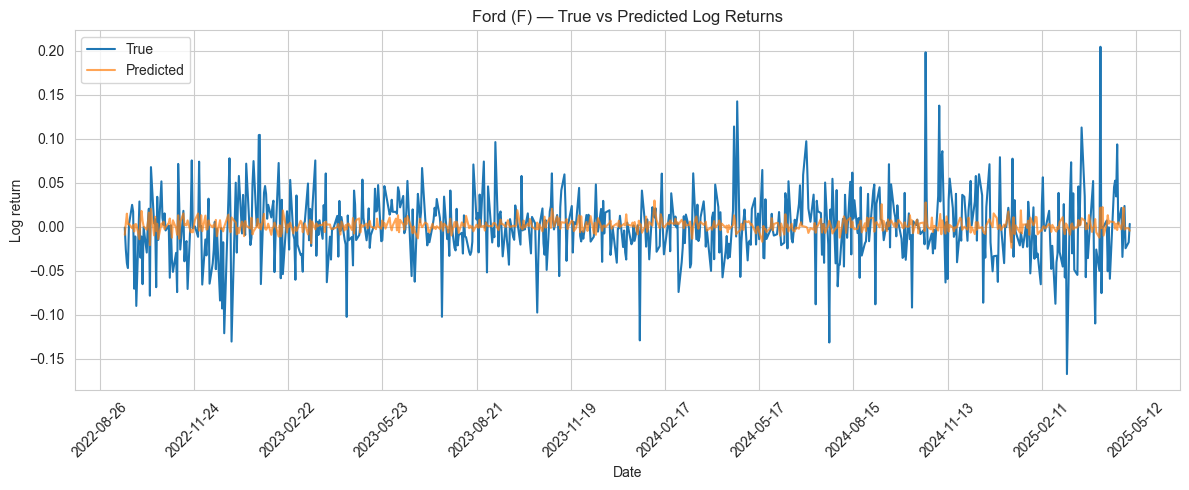

In [96]:
plt.figure(figsize=(12, 5))
plt.plot(dates_test, y_test.values, label="True")
plt.plot(dates_test, y_pred, label="Predicted", alpha=0.7)

plt.title("Ford (F) — True vs Predicted Log Returns")
plt.xlabel("Date")
plt.ylabel("Log return")
plt.legend()
plt.grid(True)

# Set x-axis major ticks every 120 days
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=90))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [97]:
coefs = best_pipe.named_steps['model'].coef_
features = best_pipe.named_steps['lags'].transform(X).columns
pd.Series(coefs, index=features).sort_values(ascending=False).head(10)

TSLA_close_open_diff        0.003655
GM_close_open_diff_lag1     0.003379
LIT_close_open_diff_lag1    0.002731
F_log_ret_lag1              0.002280
GM_high_low_spread_lag1     0.002105
LIT_log_ret                 0.001944
TM_log_ret_lag1             0.001659
DBB_high_low_spread         0.001598
LIT_high_low_spread_lag1    0.001572
TM_high_low_spread_lag1     0.001374
dtype: float64

## Random Forest and XGBoost

In [98]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

# --- LagMaker as you wrote it ---
class LagMaker(BaseEstimator, TransformerMixin):
    def __init__(self, max_lag=5):
        self.max_lag = max_lag
    def fit(self, X, y=None): 
        return self
    def transform(self, X):
        Xlag = X.copy()
        for l in range(1, self.max_lag + 1):
            Xlag = Xlag.join(X.shift(l).add_suffix(f"_lag{l}"))
        return Xlag.fillna(0)

# --- 80/20 train-test split, time-series aware (no shuffle!) ---
test_split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:test_split], X.iloc[test_split:]
y_train, y_test = y.iloc[:test_split], y.iloc[test_split:]
X_test.head()

,TSLA_high_low_spread,TM_high_low_spread,F_high_low_spread,GM_high_low_spread,LIT_high_low_spread,COPX_high_low_spread,DBB_high_low_spread,PICK_high_low_spread,TSLA_close_open_diff,TM_close_open_diff,...,COPX_volume_pct_change,DBB_volume_pct_change,PICK_volume_pct_change,TM_log_ret,F_log_ret,GM_log_ret,LIT_log_ret,COPX_log_ret,DBB_log_ret,PICK_log_ret
date,,,,,,,,,,,,,,,,,,,,,
2022-09-19,12.04,1.68,0.47,2.010,1.9000,1.23,0.3500,1.5200,8.98,1.33,...,-0.047885,-0.222162,-0.315873,0.005032,0.014165,0.034910,0.021348,0.019219,-0.004758,0.018759
2022-09-20,7.75,1.95,1.22,1.700,0.8800,0.64,0.1700,0.6100,1.82,-0.87,...,0.079741,1.193249,-0.683223,-0.005103,-0.131524,-0.057940,-0.007834,-0.025259,-0.003716,-0.016256
2022-09-21,13.17,2.43,0.54,2.025,1.6800,0.89,0.3400,0.9500,-7.49,-1.92,...,-0.439300,-0.218394,0.865986,-0.022638,-0.003060,-0.035969,-0.011455,-0.019715,-0.015006,-0.022899
2022-09-22,15.47,3.38,0.49,0.850,1.9600,0.71,0.1900,0.6694,-11.27,-1.67,...,-0.043698,0.107227,1.340280,0.010628,-0.021689,-0.007994,-0.017293,0.002058,0.005922,0.005809
2022-09-23,11.68,1.77,0.49,1.885,1.5799,1.16,0.1699,1.3000,-7.76,-0.32,...,7.593129,0.179036,0.568284,-0.012811,-0.036687,-0.052167,-0.035944,-0.059277,-0.026103,-0.050416


In [99]:
# Random Forest pipeline + lighter grid
pipe_rf = Pipeline([
    ('lags', LagMaker()),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

# 🧹 Lighten up: smaller grid, fewer combos
param_grid_rf = {
    'lags__max_lag'       : [5, 10],           # fewer lags
    'model__n_estimators' : [100],             # fewer trees
    'model__max_depth'    : [None, 5],         # max 2 depth settings
    'model__min_samples_leaf': [1, 3]          # keep just 2 options
}

# Train/test split (no CV needed, but if you *really* want CV, keep it tiny)
gscv_rf = GridSearchCV(
    pipe_rf,
    param_grid_rf,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2,
    cv=2  # or set to None and do manual test MSE after
)

gscv_rf.fit(X_train, y_train)
print("Best RF params:", gscv_rf.best_params_)
print("Best RF train CV MSE:", -gscv_rf.best_score_)
best_rf = gscv_rf.best_estimator_

Fitting 2 folds for each of 8 candidates, totalling 16 fits
Best RF params: {'lags__max_lag': 5, 'model__max_depth': 5, 'model__min_samples_leaf': 3, 'model__n_estimators': 100}
Best RF train CV MSE: 0.002569398027807413


In [100]:
pipe_xgb = Pipeline([
    ('lags', LagMaker()),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
        tree_method='hist'
    ))
])

param_grid_xgb = {
    'lags__max_lag'       : [5, 10],              # drop 15
    'model__n_estimators' : [300],                # drop 600
    'model__learning_rate': [0.05, 0.1],          # keep both
    'model__max_depth'    : [3],                  # drop 5
    'model__subsample'    : [0.8, 1.0]            # keep both
}

# 2 (lags) × 1 × 2 × 1 × 2 = **8 combinations**
gscv_xgb = GridSearchCV(
    pipe_xgb,
    param_grid_xgb,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2,
    cv=2  # more reasonable than 3
)

gscv_xgb.fit(X_train, y_train)

print("Best XGB params:", gscv_xgb.best_params_)
print("Best XGB train CV MSE:", -gscv_xgb.best_score_)
best_xgb = gscv_xgb.best_estimator_

Fitting 2 folds for each of 8 candidates, totalling 16 fits
Best XGB params: {'lags__max_lag': 5, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__subsample': 1.0}
Best XGB train CV MSE: 0.002659222784669284


Random Forest test-set MSE: 1.79780e-03


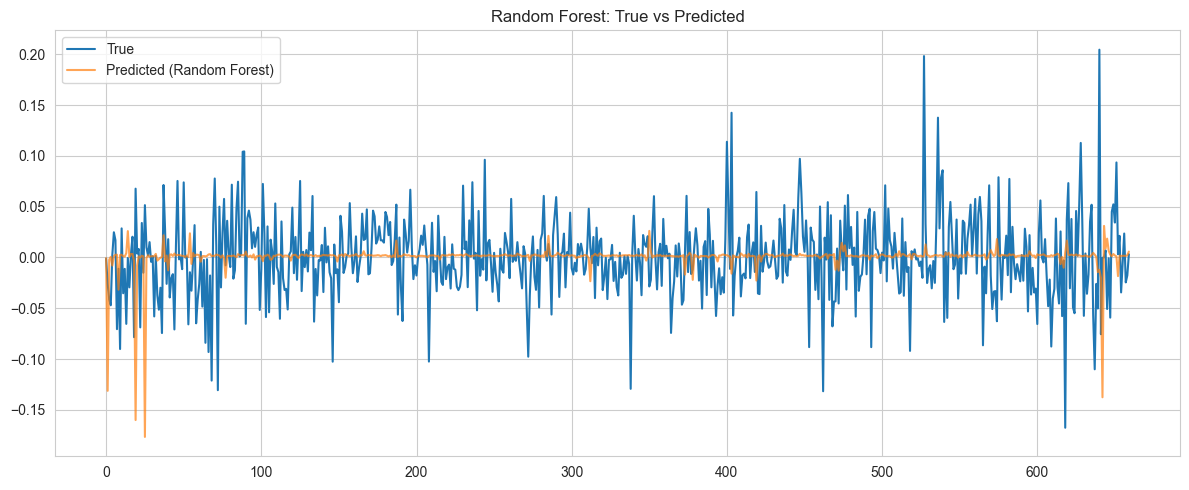

XGBoost test-set MSE: 2.10386e-03


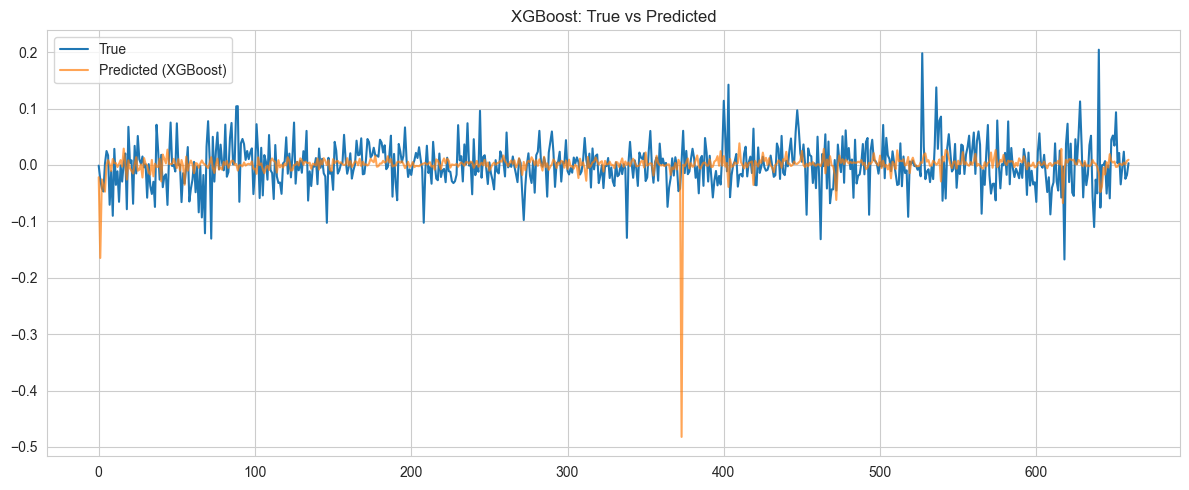

In [101]:
# --- Evaluate on test set ---
def plot_preds(model, name):
    y_hat = model.predict(X_test)
    mse = mean_squared_error(y_test, y_hat)
    print(f"{name} test-set MSE: {mse:.5e}")

    plt.figure(figsize=(12,5))
    plt.plot(y_test.values, label="True")
    plt.plot(y_hat, label=f"Predicted ({name})", alpha=0.7)
    plt.legend()
    plt.grid(True)
    plt.title(f"{name}: True vs Predicted")
    plt.tight_layout()
    plt.show()

plot_preds(best_rf, "Random Forest")
plot_preds(best_xgb, "XGBoost")

## Pytorch Neural Network

TSLA_log_ret: test MSE 1.56766e-03


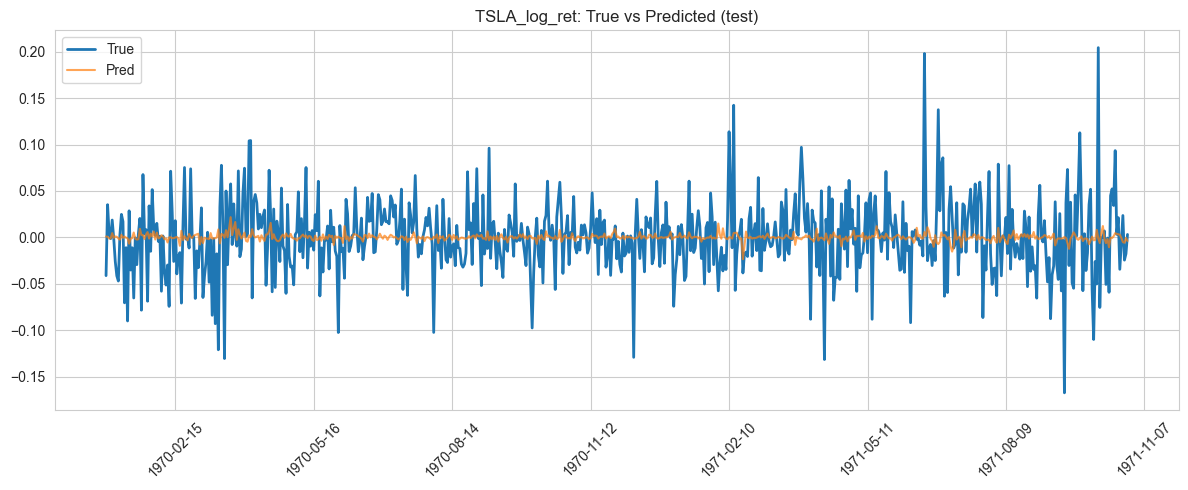

TM_log_ret: test MSE 2.94868e-04


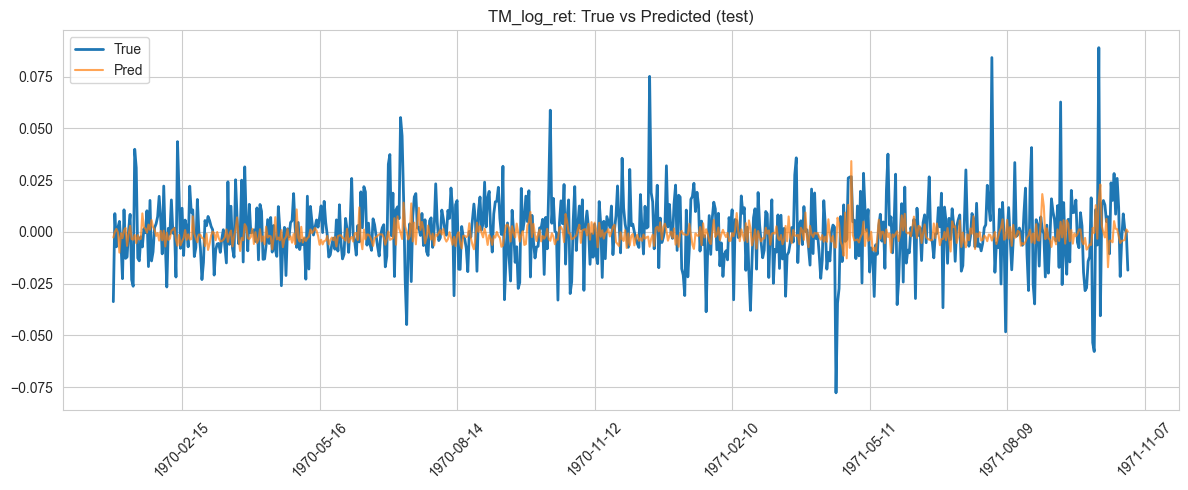

F_log_ret: test MSE 7.18073e-04


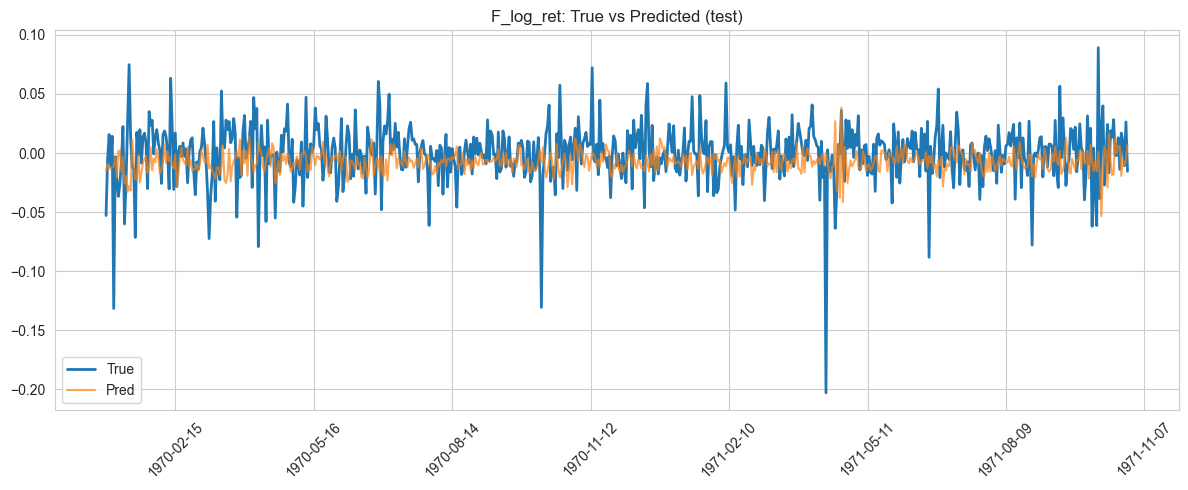

GM_log_ret: test MSE 7.02917e-04


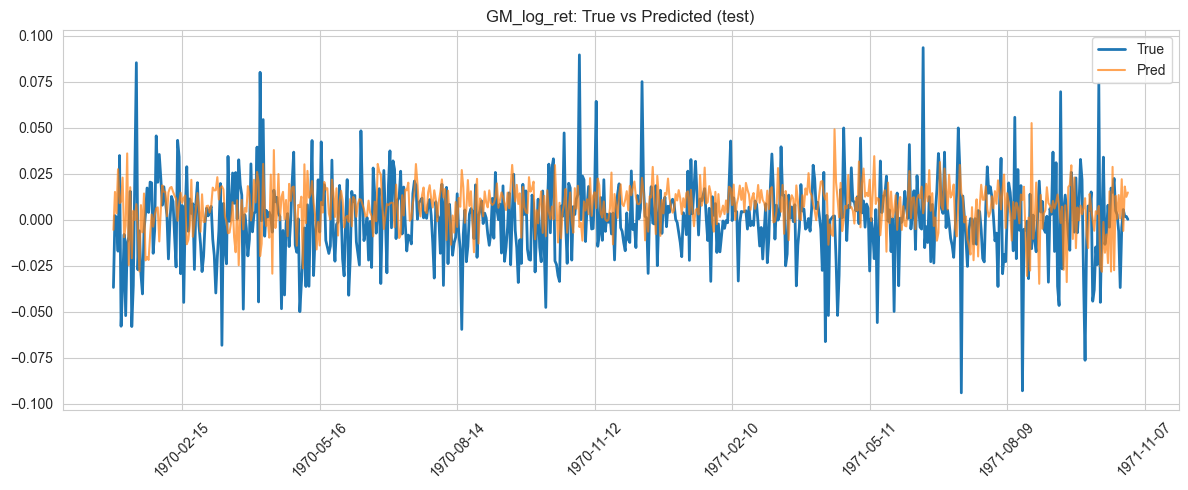


=== summary MSEs ===
TSLA_log_ret: 0.001568
TM_log_ret: 0.000295
F_log_ret: 0.000718
GM_log_ret: 0.000703


In [130]:
# LIBS ============
import itertools, matplotlib.pyplot as plt, warnings
import statsmodels.api as sm, torch, torch.nn as nn, torch.optim as optim
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
import matplotlib.dates as mdates
warnings.filterwarnings("ignore", category=FutureWarning, module="statsmodels")

# GRANGER MATRIX
max_lag, alpha = 10, 0.05
log_returns = full_df[log_ret_cols].dropna()
pv_matrix   = pd.DataFrame(np.nan, index=log_ret_cols, columns=log_ret_cols)
best_lags   = {}

for x, y in itertools.permutations(log_ret_cols, 2):          # x causes y?
    best_p, best_k = 1.0, 1
    for k in range(1, max_lag+1):
        try:
            p = sm.tsa.stattools.grangercausalitytests(
                    log_returns[[y, x]], maxlag=k, verbose=False)[k][0]['ssr_ftest'][1]
            if p < best_p:
                best_p, best_k = p, k
        except Exception: pass
    pv_matrix.loc[y, x] = best_p
    best_lags[(y, x)]   = best_k
causal_flags = pv_matrix < alpha

# LAG MAKER
class LagMaker(BaseEstimator, TransformerMixin):
    def __init__(self, max_lag=10): self.max_lag=max_lag
    def fit(self, X,y=None): return self
    def transform(self, X):
        out=[X]
        for l in range(1, self.max_lag+1):
            out.append(X.shift(l).add_suffix(f"_lag{l}"))
        res=pd.concat(out,axis=1).fillna(0)
        res.columns=res.columns.astype(str)
        return res
    
# GRANGER SELECTOR
class GrangerSelector(BaseEstimator, TransformerMixin):
    def __init__(self,target,flags,best_lags,max_lag): 
        self.t=target; self.f=flags; self.b=best_lags; self.L=max_lag
    def fit(self,X,y=None):
        causers = self.f.loc[self.t][lambda s:s].index.tolist()+[self.t]
        keep=[]
        for c in causers:
            if (self.t,c) in self.b:           # note order: y,x stored
                keep.append(f"{c}_lag{self.b[(self.t,c)]}")
            else:
                keep += [f"{c}_lag{l}" for l in range(1,self.L+1)]
        self.keep=[k for k in keep if k in X.columns]
        return self
    def transform(self,X): return X[self.keep]
    
# SIMPLE MLP
class MLP(nn.Module):
    def __init__(self, d_in, hidden=[64,32]): 
        super().__init__()
        layers=[]
        for h in hidden:
            layers += [nn.Linear(d_in, h), nn.ReLU(), nn.Dropout(0.2)]
            d_in=h
        layers+=[nn.Linear(d_in,1)]
        self.net=nn.Sequential(*layers)
    def forward(self,x): return self.net(x)

# BUILD LAGGED MATRIX
lagger = LagMaker(max_lag=max_lag)
X_lag  = lagger.fit_transform(full_df[log_ret_cols])
X_lag = X_lag.iloc[max_lag:]
dates  = X_lag.index

# LOOP EACH TARGET
device='cuda' if torch.cuda.is_available() else 'cpu'
results={}
# Collect all model outputs in one place
all_preds = []   # will hold one DataFrame per ticker
selected = [col for col in log_ret_cols if col in ['TSLA_log_ret', 'GM_log_ret', 'TM_log_ret', 'F_log_ret']]
for tgt in selected:
    y = full_df[tgt].shift(-1).loc[X_lag.index]   # next-day target
    mask = y.notna()
    X_lag_filt = X_lag.loc[mask]
    y = y.loc[mask]
    split = int(len(X_lag_filt) * 0.8)
    X_train, X_test = X_lag_filt.iloc[:split], X_lag_filt.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    # --- sklearn pipeline → numpy → torch ---
    sel = GrangerSelector(tgt, causal_flags, best_lags, max_lag)
    scaler = StandardScaler()
    Xtr_np = scaler.fit_transform(sel.fit_transform(X_train))
    Xte_np = scaler.transform(sel.transform(X_test))

    Xtr = torch.tensor(Xtr_np, dtype=torch.float32, device=device)
    Xte = torch.tensor(Xte_np, dtype=torch.float32, device=device)
    ytr = torch.tensor(y_train.values, dtype=torch.float32, device=device).unsqueeze(1)
    yte = torch.tensor(y_test.values , dtype=torch.float32, device=device).unsqueeze(1)

    model=MLP(Xtr.shape[1]).to(device)
    opt  = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.SmoothL1Loss()
    for epoch in range(150):
        model.train()
        opt.zero_grad()
        loss = loss_fn(model(Xtr), ytr)
        loss.backward()
        opt.step()
    model.eval()
    with torch.no_grad():
        y_pred = model(Xte).cpu().numpy().ravel()
    
    mse = float(((y_pred - y_test.values)**2).mean())
    results[tgt] = mse
    print(f"{tgt}: test MSE {mse:.5e}")

    # stash preds + true ret for each ticker
    all_preds.append(
        pd.DataFrame({
            'ticker'    : tgt.split('_')[0],      # e.g. 'TSLA'
            'true_ret'  : y_test.values,          # actual next-day log-ret
            'pred_ret'  : y_pred,                 # model forecast
        }, index=y_test.index)
    )

    # ---- plot ----
    plt.figure(figsize=(12,5))
    plt.plot(y_test.index, y_test.values, label='True', linewidth=2)
    plt.plot(y_test.index, y_pred,        label='Pred', alpha=0.7)
    ax=plt.gca()
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=90))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)
    plt.title(f"{tgt}: True vs Predicted (test)")
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

print("\n=== summary MSEs ===")
for k,v in results.items(): print(f"{k}: {v:.6f}")

## Trading Strategy and Backtesting

In [143]:
signals_df = (
    pd.concat(all_preds)       # list → DF
      .sort_index()            # chronological
)

# CONFIDENCE FILTER  – keep only top-20 % magnitudes
abs_bar = signals_df['pred_ret'].abs().quantile(0.90)
conf_mask = signals_df['pred_ret'].abs() > abs_bar

# PICK THE WINNER EACH DAY
# Flag the row(s) that have the daily max forecast
best_mask = (
    signals_df
      .groupby(level=0)['pred_ret']
      .transform('max')
      .eq(signals_df['pred_ret'])
)

# Position signal BEFORE timing shift
signals_df['pos_raw'] = 0
signals_df.loc[conf_mask & best_mask, 'pos_raw'] = 1   # long the daily winner

# 3. REAL-WORLD TIMING  – place trade at t, hold t+1
signals_df['position'] = (
    signals_df
      .groupby('ticker')['pos_raw']
      .shift(1)           # avoid look-ahead
      .fillna(0)
)

# STRATEGY PnL FOR THE SINGLE HELD STOCK
signals_df['strat_leg_ret'] = signals_df['position'] * signals_df['true_ret']

# Portfolio return = *sum* because only one ticker (at most) is 1
port = (
    signals_df
      .groupby(level=0)['strat_leg_ret']
      .sum()
      .to_frame('port_ret')
)
port.index = pd.to_datetime(port.index)
port.head()

,port_ret
date,
2022-09-12,0.00000
2022-09-13,0.00000
2022-09-14,0.00000
2022-09-15,0.00000
2022-09-16,0.03491


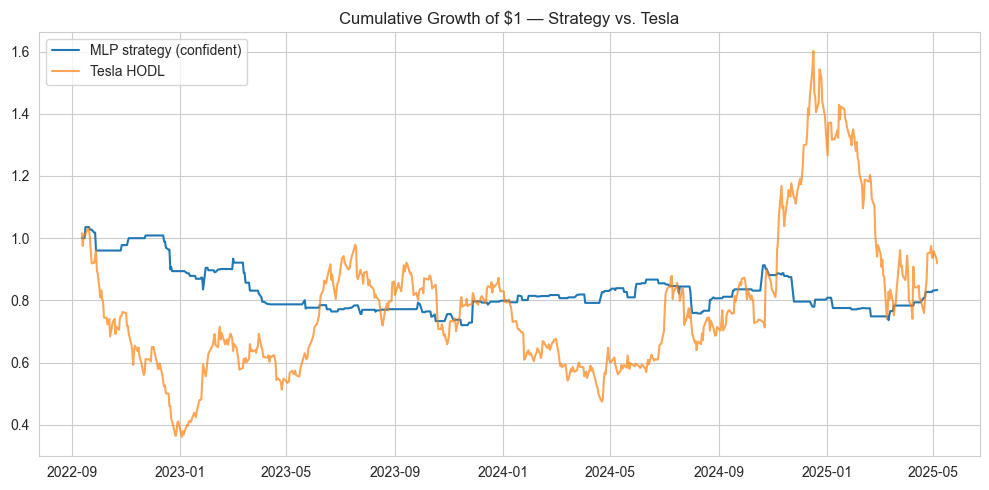

KeyError: 'mkt_ret'

In [144]:
import requests
api_key = "97OGHWS77V9ZH0G7"

# Use the free daily endpoint instead of the adjusted one
url = f"https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=TSLA&outputsize=full&apikey={api_key}"
r = requests.get(url)
data = r.json()

# Check for valid response
if "Time Series (Daily)" not in data:
    raise ValueError(f"API call failed or rate limit exceeded. Response: {data}")

# Extract time series
ts = data["Time Series (Daily)"]
df_tsla = pd.DataFrame.from_dict(ts, orient="index")

# Convert index to datetime & sort
df_tsla.index = pd.to_datetime(df_tsla.index)
df_tsla = df_tsla.sort_index()

# Convert close column to float
df_tsla['close'] = df_tsla['4. close'].astype(float)

# Calculate daily log returns
df_tsla['log_ret'] = np.log(df_tsla['close'] / df_tsla['close'].shift(1))
tsla_log_ret = df_tsla[['log_ret']].dropna().rename(columns={'log_ret': 'tsla_ret'})

df = port.join(tsla_log_ret, how='inner')

# Recalculate equity curves
df['cum_port'] = np.exp(df['port_ret'].cumsum())
df['cum_tsla'] = np.exp(df['tsla_ret'].cumsum())

plt.figure(figsize=(10,5))
plt.plot(df.index, df['cum_port'], label='MLP strategy (confident)')
plt.plot(df.index, df['cum_tsla'], label='Tesla HODL', alpha=0.7)
plt.title('Cumulative Growth of $1 — Strategy vs. Tesla')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# CAPM α / β  + risk metrics
excess_port = df['port_ret']    # rf ≈ 0 (daily)
excess_mkt  = df['mkt_ret']

X = sm.add_constant(excess_mkt)
capm = sm.OLS(excess_port, X).fit()

daily_alpha = capm.params['const']
beta        = capm.params['tsla_ret']
t_stat      = capm.tvalues['const']
ann_alpha   = (1 + daily_alpha)**252 - 1

sharpe = excess_port.mean() / excess_port.std() * np.sqrt(252)
max_dd = (df['cum_port'].cummax() - df['cum_port']).max()

print("\nCAPM results (daily-winner strategy)")
print(f"  β         : {beta:6.3f}")
print(f"  α (daily) : {daily_alpha:.6%}   | t-stat = {t_stat:5.2f}")
print(f"  α (annual): {ann_alpha:.2%}")
print(f"  Sharpe    : {sharpe:5.2f}")
print(f"  Max DD    : {max_dd:.2%}")


,mkt_ret
1999-11-02,-0.007172
1999-11-03,0.006711
1999-11-04,0.007582
1999-11-05,0.009794
1999-11-08,0.000906


In [135]:
spy_col = spy_log_ret.columns[0]
bench = spy_log_ret.loc[port.index].rename(columns={spy_col: 'mkt_ret'})

df = port.join(bench, how='inner')

df['cum_port'] = df['port_ret'].cumsum().pipe(np.exp)
df['cum_mkt']  = df['mkt_ret'] .cumsum().pipe(np.exp)

df.head()

,port_ret,mkt_ret,cum_port,cum_mkt
date,,,,
2022-09-12,0.000000,0.010690,1.000000,1.010748
2022-09-13,-0.008526,-0.044456,0.991511,0.966798
2022-09-14,0.006395,0.003809,0.997871,0.970487
2022-09-15,0.006304,-0.011418,1.004182,0.959469
2022-09-16,0.006341,-0.011758,1.010570,0.948254


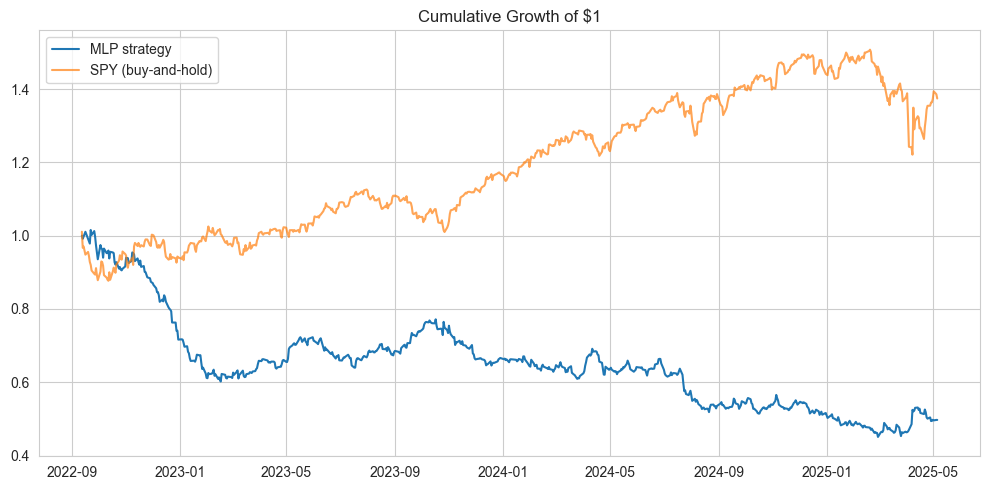


CAPM results:
  β       : -0.085
  α (daily): -0.101014%   | t-stat = -1.97
  α (ann) : -22.48%
  Sharpe  : -1.26
  Max DD  : 56.46%


In [136]:
plt.figure(figsize=(10,5))
plt.plot(df.index, df['cum_port'], label='MLP strategy')
plt.plot(df.index, df['cum_mkt'],  label='SPY (buy-and-hold)', alpha=.7)
plt.title('Cumulative Growth of $1')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# Jensen’s alpha (CAPM intercept)
# risk-free ≈ 0 for daily horizon; or pull 3-mo T-bill if you’re fancy
excess_port = df['port_ret']  # R_p - R_f
excess_mkt  = df['mkt_ret']   # R_m - R_f

X = sm.add_constant(excess_mkt)
capm = sm.OLS(excess_port, X).fit()
daily_alpha  = capm.params['const']
beta         = capm.params['mkt_ret']
t_stat       = capm.tvalues['const']

ann_alpha = (1+daily_alpha)**252 - 1     # annualise
print(f"\nCAPM results:")
print(f"  β       : {beta:6.3f}")
print(f"  α (daily): {daily_alpha:.6%}   | t-stat = {t_stat:5.2f}")
print(f"  α (ann) : {ann_alpha:.2%}")

# Bonus risk metrics / QC vibes
sharpe = excess_port.mean() / excess_port.std() * np.sqrt(252)
max_dd = (df['cum_port'].cummax() - df['cum_port']).max()
print(f"  Sharpe  : {sharpe:5.2f}")
print(f"  Max DD  : {max_dd:.2%}")

In [102]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from datetime import timedelta

# Purged K Fold for train test split
class PurgedKFold:
    def __init__(self, n_splits=5, purge_days=10, dates=None):
        self.n_splits  = n_splits
        self.purge_days = purge_days
        self.dates = pd.to_datetime(pd.Series(dates)).sort_values().reset_index(drop=True)

    def split(self, X):
        fold_sizes = np.full(self.n_splits, len(X) // self.n_splits, dtype=int)
        fold_sizes[:len(X) % self.n_splits] += 1
        starts = np.cumsum(fold_sizes)[:-1]

        for start, size in zip(np.r_[0, starts], fold_sizes):
            test_idx = np.arange(start, start + size)
            t0, t1   = self.dates.iloc[test_idx[[0, -1]]]

            purge_mask = (self.dates >= t0 - timedelta(days=self.purge_days)) & \
                         (self.dates <= t1 + timedelta(days=self.purge_days))
            train_idx = np.where(~purge_mask)[0]
            yield train_idx, test_idx

# Lag Dataset to hypertune lag feature
class LagDataset:
    def __init__(self, X_df: pd.DataFrame, y_ser: pd.Series, max_lag=5):
        lagged_parts = [X_df]
        for lag in range(1, max_lag + 1):
            lagged_parts.append(X_df.shift(lag).add_suffix(f"_lag{lag}"))
        X_lag = pd.concat(lagged_parts, axis=1).fillna(0)

        y_shift = y_ser.shift(-1).fillna(0)  # next-step target

        # scale features
        scaler = StandardScaler()
        self.X = torch.tensor(scaler.fit_transform(X_lag), dtype=torch.float32)
        self.y = torch.tensor(y_shift.values,               dtype=torch.float32).unsqueeze(1)

# MLP REGRESSOR
class MLP(nn.Module):
    def __init__(self, input_dim, hidden=[128, 64, 32], act='relu'):
        super().__init__()
        f = nn.ReLU() if act=='relu' else nn.Tanh()
        layers = []
        prev = input_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), f]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

# DATALOADERS
def make_dls(X, y, tr_idx, val_idx, bs=64):
    # Convert indices to lists or tensors
    tr_idx = torch.tensor(tr_idx, dtype=torch.long)
    val_idx = torch.tensor(val_idx, dtype=torch.long)

    tr_ds = TensorDataset(X[tr_idx], y[tr_idx])
    val_ds = TensorDataset(X[val_idx], y[val_idx])

    tr_dl = DataLoader(tr_ds, batch_size=bs, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=bs, shuffle=False)

    return tr_dl, val_dl

# CV TRAIN LOOP
def cv_train(full_X, full_y, dates,
             hidden=[128,64,32], lr=1e-3, epochs=50,
             n_splits=5, purge_days=10, bs=256, device='cpu'):

    pkf = PurgedKFold(n_splits, purge_days, dates)
    fold_losses = []
    all_models = []
    all_preds = []
    all_val_idxs = []

    for k,(tr,va) in enumerate(pkf.split(full_X)):
        print(f"\nFold {k+1}/{n_splits}")
        tr_dl, va_dl = make_dls(full_X, full_y, tr, va, bs)

        model = MLP(full_X.shape[1], hidden).to(device)
        opt   = optim.Adam(model.parameters(), lr=lr)
        crit  = nn.SmoothL1Loss()

        best = 1e9; patience=5; wait=0
        for ep in range(1, epochs+1):
            # train
            model.train()
            for xb,yb in tr_dl:
                xb,yb = xb.to(device), yb.to(device)
                opt.zero_grad()
                loss = crit(model(xb), yb)
                loss.backward(); opt.step()

            # validate
            model.eval(); val = 0
            with torch.no_grad():
                for xb,yb in va_dl:
                    xb,yb = xb.to(device), yb.to(device)
                    val += crit(model(xb), yb).item()
            val /= len(va_dl)
            print(f"   ep {ep:02d} | val {val:.5f}")

            if val < best - 1e-5:
                best_model = model.state_dict()
                best, wait = val, 0
            else:
                wait += 1
                if wait >= patience:
                    print("early stop"); break

        # reload best weights
        model.load_state_dict(best_model)
        model.eval()

        # collect validation predictions
        val_preds = torch.zeros(len(va), 1)
        with torch.no_grad():
            for i, idx in enumerate(va):
                x = full_X[idx].unsqueeze(0).to(device)
                val_preds[i] = model(x).cpu()

        fold_losses.append(best)
        all_models.append(model)
        all_preds.append(val_preds)
        all_val_idxs.append(va)

    print(f"\nCV mean {np.mean(fold_losses):.5f} ± {np.std(fold_losses):.5f}")
    return fold_losses, all_models, all_preds, all_val_idxs

X_df = full_df.drop(columns=['GM_log_ret'])
X_df.replace([np.inf, -np.inf], np.nan, inplace=True)
X_df.dropna(inplace=True)

y_ser = full_df.loc[X_df.index, 'GM_log_ret'].shift(-1)
y_ser.dropna(inplace=True)
X_df = X_df.loc[y_ser.index]

lag_ds  = LagDataset(X_df, y_ser, max_lag=5)

print("X shape:", lag_ds.X.shape)
print("y shape:", lag_ds.y.shape)
print("full_df index length:", len(full_df.index))

cv_train(lag_ds.X, lag_ds.y, X_df.index,
          hidden=[128,64,32], lr=1e-3, epochs=100,
          n_splits=5, purge_days=10,
          device='cuda' if torch.cuda.is_available() else 'cpu')

X shape: torch.Size([3298, 186])
y shape: torch.Size([3298, 1])
full_df index length: 3335

Fold 1/5
   ep 01 | val 0.00080
   ep 02 | val 0.00053
   ep 03 | val 0.00039
   ep 04 | val 0.00037
   ep 05 | val 0.00030
   ep 06 | val 0.00028
   ep 07 | val 0.00030
   ep 08 | val 0.00029
   ep 09 | val 0.00027
   ep 10 | val 0.00027
   ep 11 | val 0.00027
   ep 12 | val 0.00027
   ep 13 | val 0.00027
   ep 14 | val 0.00027
early stop

Fold 2/5
   ep 01 | val 0.00035
   ep 02 | val 0.00023
   ep 03 | val 0.00019
   ep 04 | val 0.00019
   ep 05 | val 0.00020
   ep 06 | val 0.00020
   ep 07 | val 0.00020
   ep 08 | val 0.00021
early stop

Fold 3/5
   ep 01 | val 0.00102
   ep 02 | val 0.00060
   ep 03 | val 0.00032
   ep 04 | val 0.00035
   ep 05 | val 0.00028
   ep 06 | val 0.00029
   ep 07 | val 0.00025
   ep 08 | val 0.00025
   ep 09 | val 0.00026
   ep 10 | val 0.00023
   ep 11 | val 0.00024
   ep 12 | val 0.00022
   ep 13 | val 0.00023
   ep 14 | val 0.00023
   ep 15 | val 0.00023
early 

([0.000271854514721781,
  0.00019397934374865144,
  0.00023268907777188966,
  0.0007391139515675604,
  0.00032032384964016575],
 [MLP(
    (net): Sequential(
      (0): Linear(in_features=186, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=32, bias=True)
      (5): ReLU()
      (6): Linear(in_features=32, out_features=1, bias=True)
    )
  ),
  MLP(
    (net): Sequential(
      (0): Linear(in_features=186, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=32, bias=True)
      (5): ReLU()
      (6): Linear(in_features=32, out_features=1, bias=True)
    )
  ),
  MLP(
    (net): Sequential(
      (0): Linear(in_features=186, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=64, bias=True)
      (


Fold 1/5
   ep 01 | val 0.00019
   ep 02 | val 0.00016
   ep 03 | val 0.00016
   ep 04 | val 0.00016
   ep 05 | val 0.00016
   ep 06 | val 0.00017
   ep 07 | val 0.00018
early stop

Fold 2/5
   ep 01 | val 0.00027
   ep 02 | val 0.00016
   ep 03 | val 0.00015
   ep 04 | val 0.00016
   ep 05 | val 0.00017
   ep 06 | val 0.00017
   ep 07 | val 0.00018
early stop

Fold 3/5
   ep 01 | val 0.00027
   ep 02 | val 0.00019
   ep 03 | val 0.00017
   ep 04 | val 0.00017
   ep 05 | val 0.00016
   ep 06 | val 0.00016
   ep 07 | val 0.00017
   ep 08 | val 0.00017
early stop

Fold 4/5
   ep 01 | val 0.00267
   ep 02 | val 0.00137
   ep 03 | val 0.00106
   ep 04 | val 0.00098
   ep 05 | val 0.00092
   ep 06 | val 0.00088
   ep 07 | val 0.00087
   ep 08 | val 0.00086
   ep 09 | val 0.00085
   ep 10 | val 0.00085
   ep 11 | val 0.00085
   ep 12 | val 0.00085
   ep 13 | val 0.00085
   ep 14 | val 0.00085
early stop

Fold 5/5
   ep 01 | val 0.00055
   ep 02 | val 0.00038
   ep 03 | val 0.00035
   ep 04 

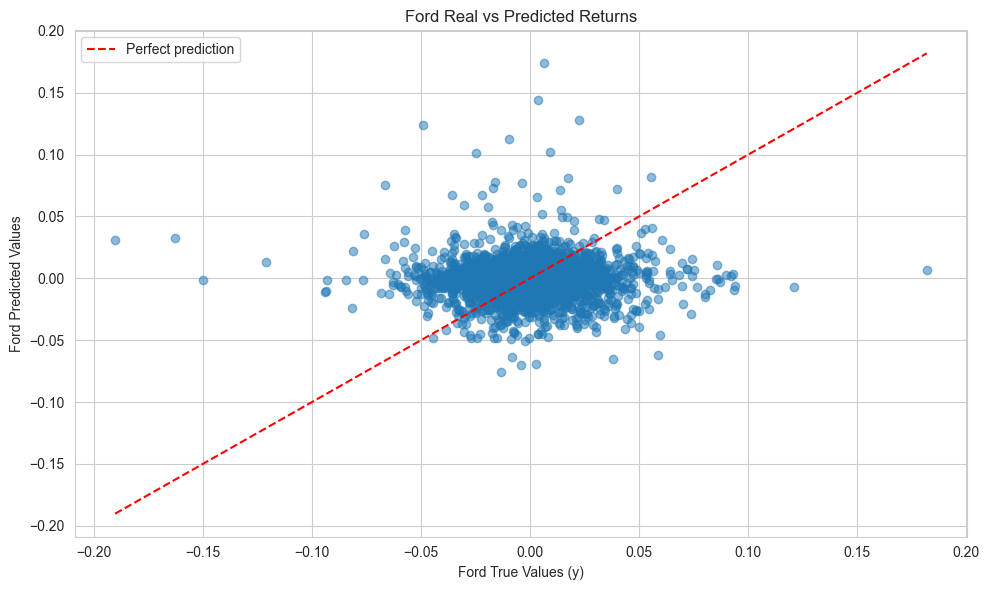

In [103]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Run the training
losses, models, preds_list, val_idxs_list = cv_train(lag_ds.X, lag_ds.y, X_df.index,
                                                     hidden=[128,64,32], lr=1e-3, epochs=100,
                                                     n_splits=5, purge_days=10,
                                                     device='cuda' if torch.cuda.is_available() else 'cpu')

# Combine predictions and true values for all folds
all_preds = torch.cat(preds_list).squeeze().numpy()
all_val_idxs = np.concatenate(val_idxs_list)
true_vals = lag_ds.y[all_val_idxs].squeeze().numpy()

# Calculate MSE
mse = mean_squared_error(true_vals, all_preds)
print(f"\nFord Overall MSE: {mse:.5f}")

# Plotting real vs predicted
plt.figure(figsize=(10, 6))
plt.scatter(true_vals, all_preds, alpha=0.5)
plt.plot([true_vals.min(), true_vals.max()], [true_vals.min(), true_vals.max()], 'r--', label="Perfect prediction")
plt.xlabel("Ford True Values (y)")
plt.ylabel("Ford Predicted Values")
plt.title("Ford Real vs Predicted Returns")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

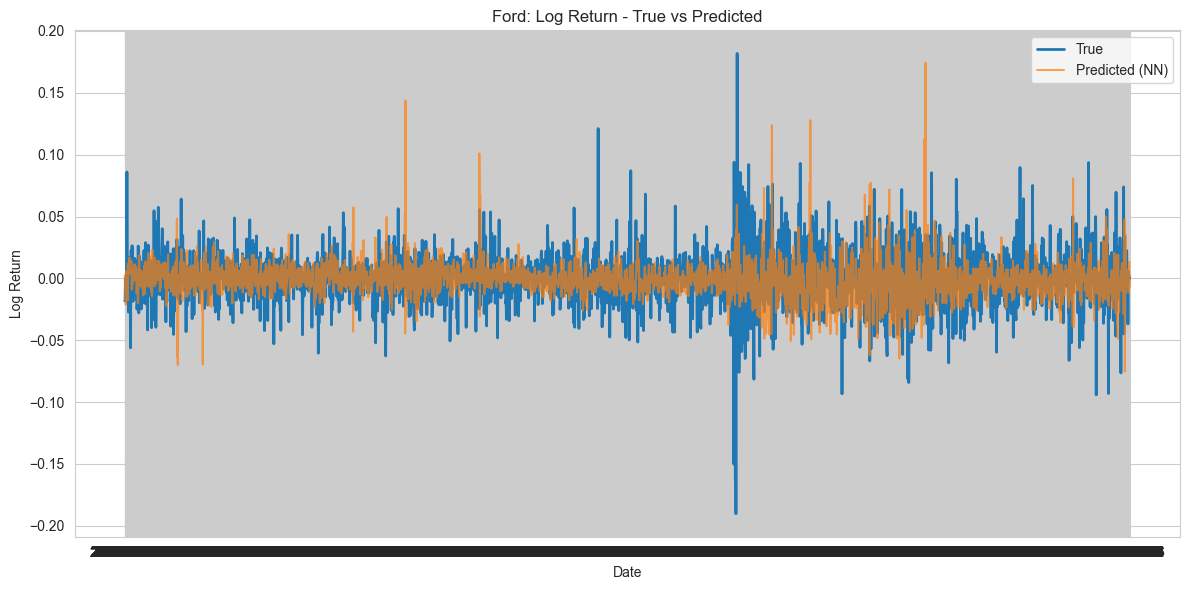

In [104]:
# Combine validation indices and predictions
all_val_idxs = np.concatenate(val_idxs_list)
all_preds = torch.cat(preds_list).squeeze().numpy()
true_vals = lag_ds.y[all_val_idxs].squeeze().numpy()

# Sort by index to align with time
sorted_idx = np.argsort(all_val_idxs)
sorted_dates = X_df.index[all_val_idxs][sorted_idx]
y_sorted = true_vals[sorted_idx]
y_hat_sorted = all_preds[sorted_idx]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(sorted_dates, y_sorted, label="True", linewidth=2)
plt.plot(sorted_dates, y_hat_sorted, label="Predicted (NN)", alpha=0.7)
plt.legend()
plt.title("Ford: Log Return - True vs Predicted")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(True)
plt.tight_layout()
plt.show()